In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [57]:
df_path = "../../../data/France/Paris Sell In Data.csv"


MONTH_COLS = ['Jan-26', 'Feb-26', 'Mar-26']

df = pd.read_csv(df_path)

df['TotalSales'] = df[MONTH_COLS].sum(axis=1)

df['Growth_Jan_Feb'] = ((df['Feb-26'] - df['Jan-26']) / df['Jan-26'] * 100).round(2)
df['Growth_Feb_Mar'] = ((df['Mar-26'] - df['Feb-26']) / df['Feb-26'] * 100).round(2)

print(f"Shape          : {df.shape}")
print(f"Outlets        : {df['Local Outlet Code'].nunique()}")
print(f"SKUs           : {df['Local SKU Code'].nunique()}")
print(f"Categories     : {df['Category'].unique().tolist()}")
print(f"Null values    : {df.isnull().sum().sum()}")
print()
print("── Monthly Totals ──")
for m in MONTH_COLS:
    print(f"  {m}: {df[m].sum():>12,.0f} units")
print(f"  MoM Growth Jan→Feb: {((df['Feb-26'].sum() - df['Jan-26'].sum()) / df['Jan-26'].sum() * 100):.1f}%")
print(f"  MoM Growth Feb→Mar: {((df['Mar-26'].sum() - df['Feb-26'].sum()) / df['Feb-26'].sum() * 100):.1f}%")
print()
df.head()

Shape          : (11516, 15)
Outlets        : 663
SKUs           : 126
Categories     : ['FMC', 'Oral', 'RYO', 'Vapour Liquids', 'Vapour Devices', '0']
Null values    : 0

── Monthly Totals ──
  Jan-26:   12,570,109 units
  Feb-26:   12,892,490 units
  Mar-26:   13,959,506 units
  MoM Growth Jan→Feb: 2.6%
  MoM Growth Feb→Mar: 8.3%



,Local Outlet Code,Outlet SF ID,Outlet Name,Local SKU Code,SKU SF ID,SKU Name,Category,Jan-26,Feb-26,Mar-26,CITY NAME,CITY CODE,TotalSales,Growth_Jan_Feb,Growth_Feb_Mar
0,304008,0011t000011bCB2AAM,304008 - GASCOGNE (SNC LA),125,a0U1t000002PXloEAG,125 - LUCKY STRIKE RED 20,FMC,1600,2000,1200,PARIS,a2d3W000000HIPWQA4,4800,25.00,-40.00
1,304008,0011t000011bCB2AAM,304008 - GASCOGNE (SNC LA),1186,a0U1t000002PXpKEAW,1186 - PETER STUYVESANT ROUGE LONGUES EN 20,FMC,200,200,200,PARIS,a2d3W000000HIPWQA4,600,0.00,0.00
2,304008,0011t000011bCB2AAM,304008 - GASCOGNE (SNC LA),1562,a0U1t000002PXpzEAG,1562 - ROTHMANS BLEU EN 20,FMC,1400,2600,3400,PARIS,a2d3W000000HIPWQA4,7400,85.71,30.77
3,304008,0011t000011bCB2AAM,304008 - GASCOGNE (SNC LA),2671,a0U1t000002PXn1EAG,2671 - DUNHILL INTERNATIONAL BLEU EN 20,FMC,200,200,400,PARIS,a2d3W000000HIPWQA4,800,0.00,100.00
4,304008,0011t000011bCB2AAM,304008 - GASCOGNE (SNC LA),3010,a0U1t000002PXkTEAW,3010 - ROTHMANS ROUGE EN 20,FMC,400,200,400,PARIS,a2d3W000000HIPWQA4,1000,-50.00,100.00


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11516 entries, 0 to 11515
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Local Outlet Code  11516 non-null  int64  
 1   Outlet SF ID       11516 non-null  object 
 2   Outlet Name        11516 non-null  object 
 3   Local SKU Code     11516 non-null  int64  
 4   SKU SF ID          11516 non-null  object 
 5   SKU Name           11516 non-null  object 
 6   Category           11516 non-null  object 
 7   Jan-26             11516 non-null  int64  
 8   Feb-26             11516 non-null  int64  
 9   Mar-26             11516 non-null  int64  
 10  CITY NAME          11516 non-null  object 
 11  CITY CODE          11516 non-null  object 
 12  TotalSales         11516 non-null  int64  
 13  Growth_Jan_Feb     11516 non-null  float64
 14  Growth_Feb_Mar     11516 non-null  float64
dtypes: float64(2), int64(6), object(7)
memory usage: 1.3+ MB


- We don't have any null values

In [59]:
df.describe()

,Local Outlet Code,Local SKU Code,Jan-26,Feb-26,Mar-26,TotalSales,Growth_Jan_Feb,Growth_Feb_Mar
count,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000,11516.000000
mean,313785.590135,43016.510768,1091.534300,1119.528482,1212.183571,3423.246353,27.245670,34.839759
std,46118.734650,37859.859325,1573.505223,1600.415071,1722.024004,4571.034280,101.967531,106.446521
min,300001.000000,125.000000,4.000000,5.000000,5.000000,15.000000,-97.560000,-99.000000
25%,302130.000000,2660.000000,200.000000,200.000000,200.000000,1000.000000,-33.330000,-25.000000
50%,305050.000000,58811.000000,600.000000,600.000000,600.000000,1800.000000,0.000000,0.000000
75%,308049.000000,85548.000000,1200.000000,1200.000000,1400.000000,4000.000000,50.000000,66.670000
max,579082.000000,88898.000000,25000.000000,25000.000000,30000.000000,75000.000000,1800.000000,2100.000000


In [60]:
# Count unique value counts in each. 
columns = df.columns.to_list()

# Each row is a unique combination of (One Outlet * One SKU Combination)

# Check for unique stores and sku
df['Local Outlet Code'].nunique(),  df['Local SKU Code'].nunique()

(663, 126)

## Exploratory Data Analysis (EDA)

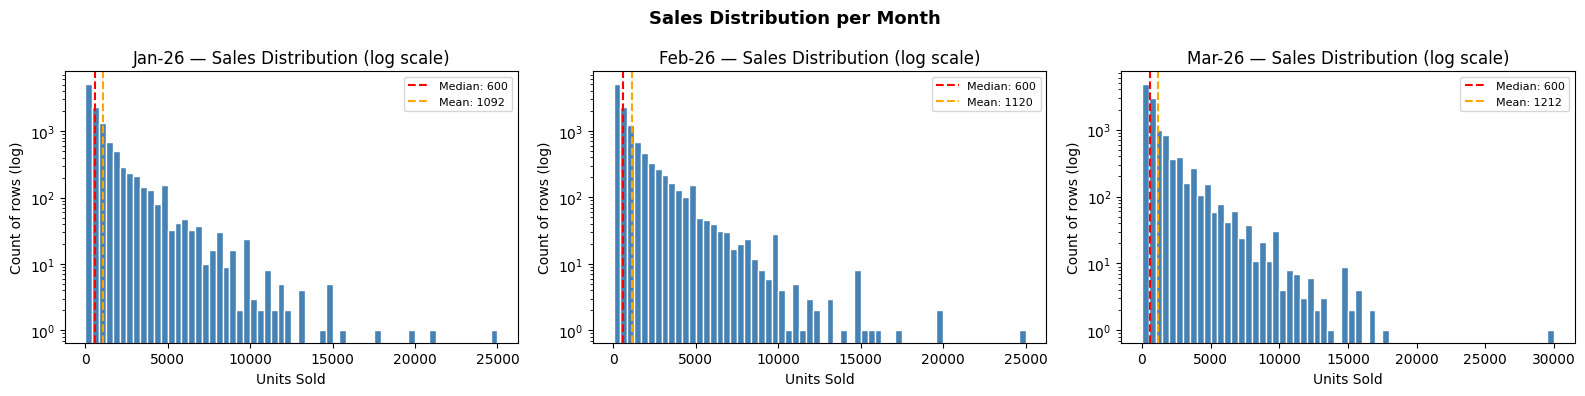

Sales statistics per month:
        Jan-26   Feb-26   Mar-26
count  11516.0  11516.0  11516.0
mean    1091.5   1119.5   1212.2
std     1573.5   1600.4   1722.0
min        4.0      5.0      5.0
25%      200.0    200.0    200.0
50%      600.0    600.0    600.0
75%     1200.0   1200.0   1400.0
max    25000.0  25000.0  30000.0


In [61]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(MONTH_COLS):
    axes[i].hist(df[col], bins=60, color='steelblue', edgecolor='white', log=True)
    axes[i].set_title(f'{col} — Sales Distribution (log scale)')
    axes[i].set_xlabel('Units Sold')
    axes[i].set_ylabel('Count of rows (log)')
    axes[i].axvline(df[col].median(), color='red',    linestyle='--', label=f'Median: {df[col].median():.0f}')
    axes[i].axvline(df[col].mean(),   color='orange', linestyle='--', label=f'Mean: {df[col].mean():.0f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Sales Distribution per Month', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Sales statistics per month:")
print(df[MONTH_COLS].describe().round(1).to_string())

The sales data are clearly right skewed with very few high sales data 

In [62]:
cat_monthly = df.groupby('Category')[MONTH_COLS].sum()

cat_monthly['Total'] = cat_monthly.sum(axis=1)
cat_monthly['Share%'] = (cat_monthly['Total'] / cat_monthly['Total'].sum() * 100).round(3)

cat_monthly

,Jan-26,Feb-26,Mar-26,Total,Share%
Category,,,,,
0,325,287,296,908,0.002
FMC,12234280,12560140,13576460,38370880,97.333
Oral,7370,7010,4165,18545,0.047
RYO,308200,305700,356400,970300,2.461
Vapour Devices,2013,2086,2067,6166,0.016
Vapour Liquids,17921,17267,20118,55306,0.140


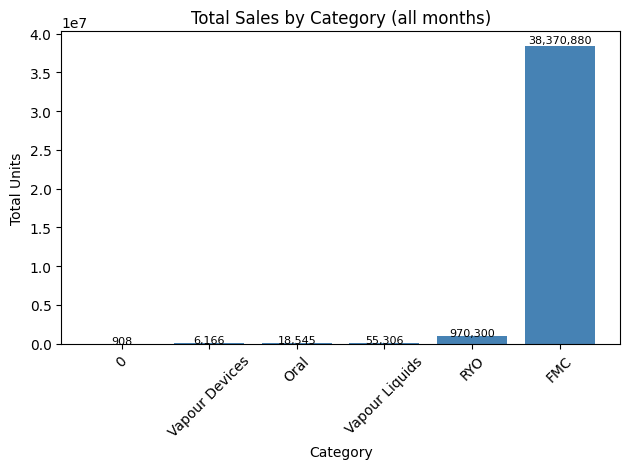

In [63]:
data = cat_monthly['Total'].sort_values()

fig, ax = plt.subplots()
ax.bar(data.index, data.values, color='steelblue')

ax.set_title('Total Sales by Category (all months)')
ax.set_xlabel('Category')
ax.set_ylabel('Total Units')

plt.xticks(rotation=45)

for i, v in enumerate(data.values):
    ax.text(i, v * 1.01, f'{v:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

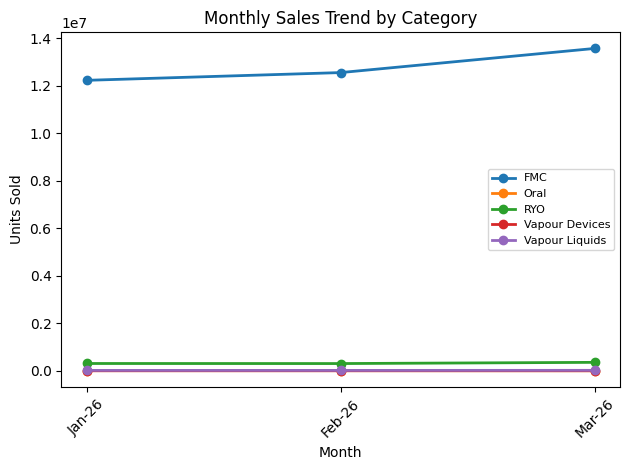

In [64]:
# 2. Monthly trend per category (exclude '0' category)
fig, ax = plt.subplots()
cat_trend = cat_monthly[cat_monthly.index != '0'][MONTH_COLS]
for cat in cat_trend.index:
    y_values = cat_trend.loc[cat].values
    x_values = MONTH_COLS
    ax.plot(x_values, y_values, marker='o', linewidth=2, label=cat)

# Titles and labels
ax.set_title('Monthly Sales Trend by Category')
ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')

# Rotate month labels if needed
plt.xticks(rotation=45)

# Legend
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [73]:
outlet_agg = df.groupby(['Local Outlet Code', 'Outlet Name']).agg(
    Jan   = ('Jan-26',    'sum'),
    Feb   = ('Feb-26',    'sum'),
    Mar   = ('Mar-26',    'sum'),
    Total = ('TotalSales','sum'),
    SKUs  = ('Local SKU Code','nunique')
).reset_index().sort_values('Total', ascending=False)

outlet_agg['Growth_Jan_Mar%'] = ((outlet_agg['Mar'] - outlet_agg['Jan']) / outlet_agg['Jan'] * 100).round(1)

outlet_agg

,Local Outlet Code,Outlet Name,Jan,Feb,Mar,Total,SKUs,Growth_Jan_Mar%
1,300002,326231 - ST LAZARE TABAC V 12 SNCF,99960,101700,79740,281400,24,-20.2
595,309176,309176 - PROGRES (LE),67483,73127,101012,241622,44,49.7
163,302153,302153 - VOLTAIRE (LE),37759,74019,105633,217411,35,179.8
4,300005,300005 - HAVANE (LA),64596,71476,71936,208008,35,11.4
386,306009,306009 - Beau drugstore,74308,56781,59132,190221,40,-20.4
...,...,...,...,...,...,...,...,...
583,309133,372185 - CONSEIL ECO.ET SOCIAL,200,800,200,1200,1,0.0
470,307129,307129 - JEAN BART (LE),400,200,200,800,1,-50.0
552,309004,309004 - ESPACE TABAC (L'),235,230,245,710,3,4.3
591,309158,309158 - VIZIR (LE),50,85,125,260,3,150.0


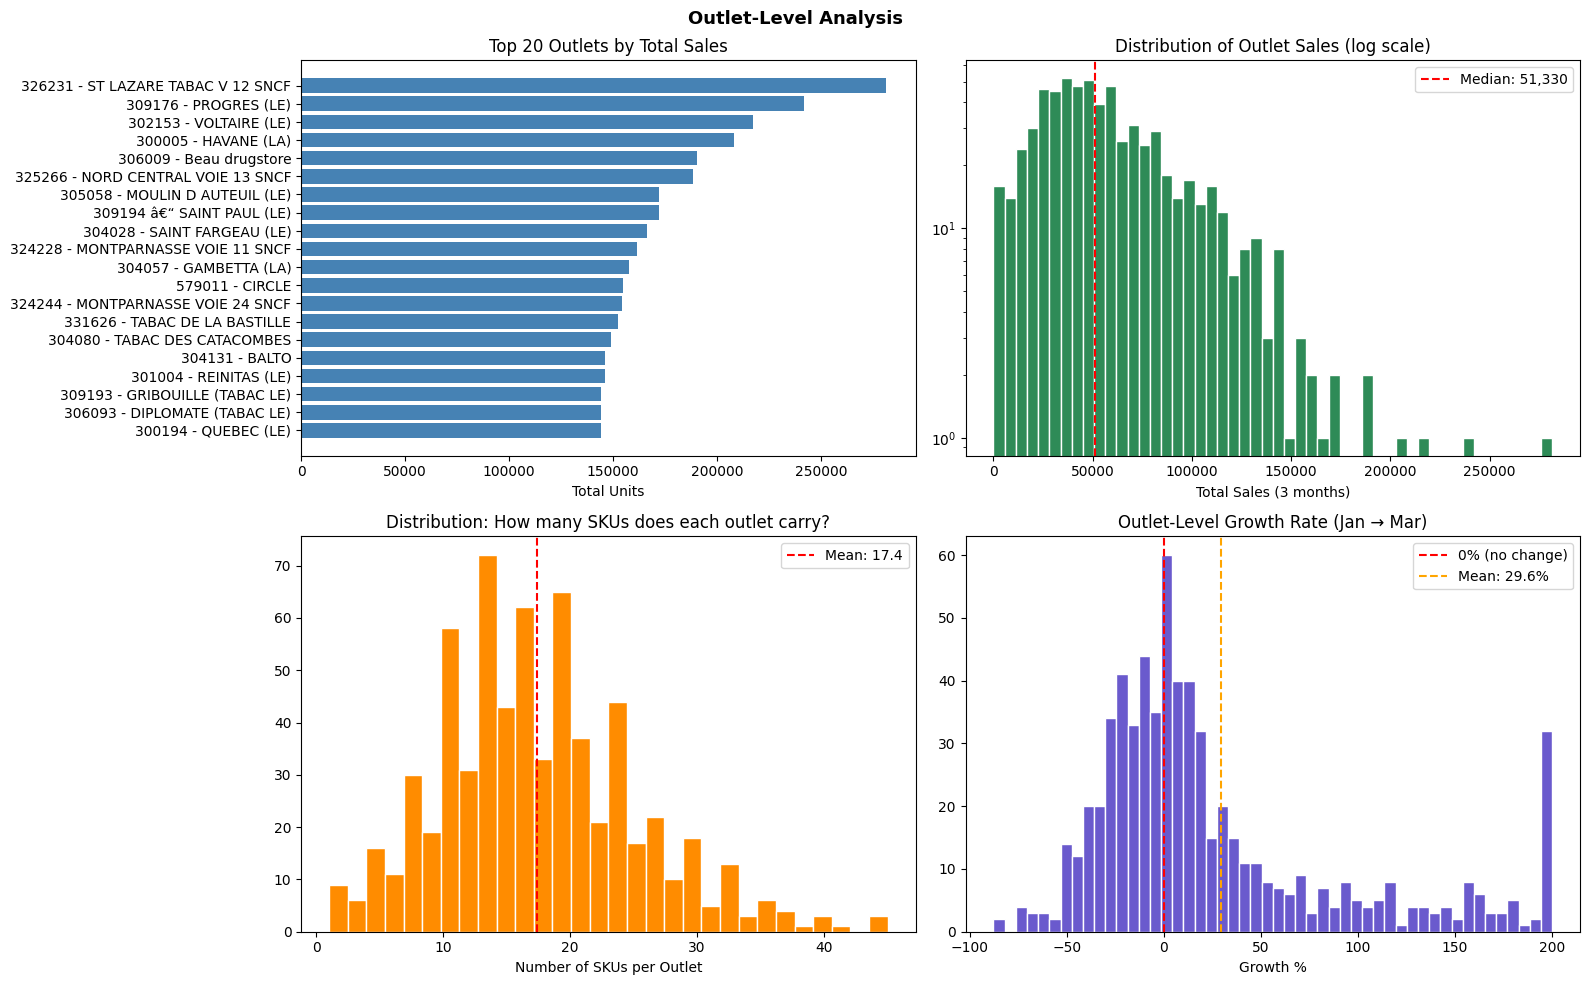

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Top 20 outlets
top20 = outlet_agg.head(20)
axes[0,0].barh(top20['Outlet Name'].str[:35], top20['Total'], color='steelblue')
axes[0,0].invert_yaxis()
axes[0,0].set_title('Top 20 Outlets by Total Sales')
axes[0,0].set_xlabel('Total Units')

# 2. Distribution of outlet total sales
axes[0,1].hist(outlet_agg['Total'], bins=50, color='seagreen', edgecolor='white', log=True)
axes[0,1].set_title('Distribution of Outlet Sales (log scale)')
axes[0,1].set_xlabel('Total Sales (3 months)')
axes[0,1].axvline(outlet_agg['Total'].median(), color='red', linestyle='--',
                  label=f"Median: {outlet_agg['Total'].median():,.0f}")
axes[0,1].legend()

# 3. SKUs per outlet distribution
axes[1,0].hist(outlet_agg['SKUs'], bins=30, color='darkorange', edgecolor='white')
axes[1,0].set_title('Distribution: How many SKUs does each outlet carry?')
axes[1,0].set_xlabel('Number of SKUs per Outlet')
axes[1,0].axvline(outlet_agg['SKUs'].mean(), color='red', linestyle='--',
                  label=f"Mean: {outlet_agg['SKUs'].mean():.1f}")
axes[1,0].legend()

# 4. Outlet growth Jan to Mar
axes[1,1].hist(outlet_agg['Growth_Jan_Mar%'].clip(-100,200), bins=50,
               color='slateblue', edgecolor='white')
axes[1,1].set_title('Outlet-Level Growth Rate (Jan → Mar)')
axes[1,1].set_xlabel('Growth %')
axes[1,1].axvline(0, color='red', linestyle='--', label='0% (no change)')
axes[1,1].axvline(outlet_agg['Growth_Jan_Mar%'].mean(), color='orange',
                  linestyle='--', label=f"Mean: {outlet_agg['Growth_Jan_Mar%'].mean():.1f}%")
axes[1,1].legend()

plt.suptitle('Outlet-Level Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [81]:
sku_agg = df.groupby(['Local SKU Code','SKU Name','Category']).agg(
    Jan      = ('Jan-26',    'sum'),
    Feb      = ('Feb-26',    'sum'),
    Mar      = ('Mar-26',    'sum'),
    Total    = ('TotalSales','sum'),
    Outlets  = ('Local Outlet Code','nunique')
).reset_index().sort_values('Total', ascending=False)

sku_agg['Growth_Jan_Mar%'] = ((sku_agg['Mar'] - sku_agg['Jan']) / sku_agg['Jan'] * 100).round(1)
print(sku_agg.shape)
sku_agg.head()

(126, 9)


,Local SKU Code,SKU Name,Category,Jan,Feb,Mar,Total,Outlets,Growth_Jan_Mar%
13,3721,3721 - VOGUE ORIGINALE BLEUE EN 20,FMC,2295400,2467280,2710180,7472860,591,18.1
43,85548,85548 - VOGUE Lâ€™ORIGINALE VERTE ICE 20s,FMC,1712200,1860760,1960780,5533740,582,14.5
0,125,125 - LUCKY STRIKE RED 20,FMC,1543000,1595200,1709380,4847580,571,10.8
16,6414,6414 - VOGUE ORIGINALE PASTEL EN 20,FMC,1473600,1489800,1560780,4524180,569,5.9
4,1201,1201 - LUCKY STRIKE BLEU EN 20,FMC,846800,845560,912600,2604960,531,7.8


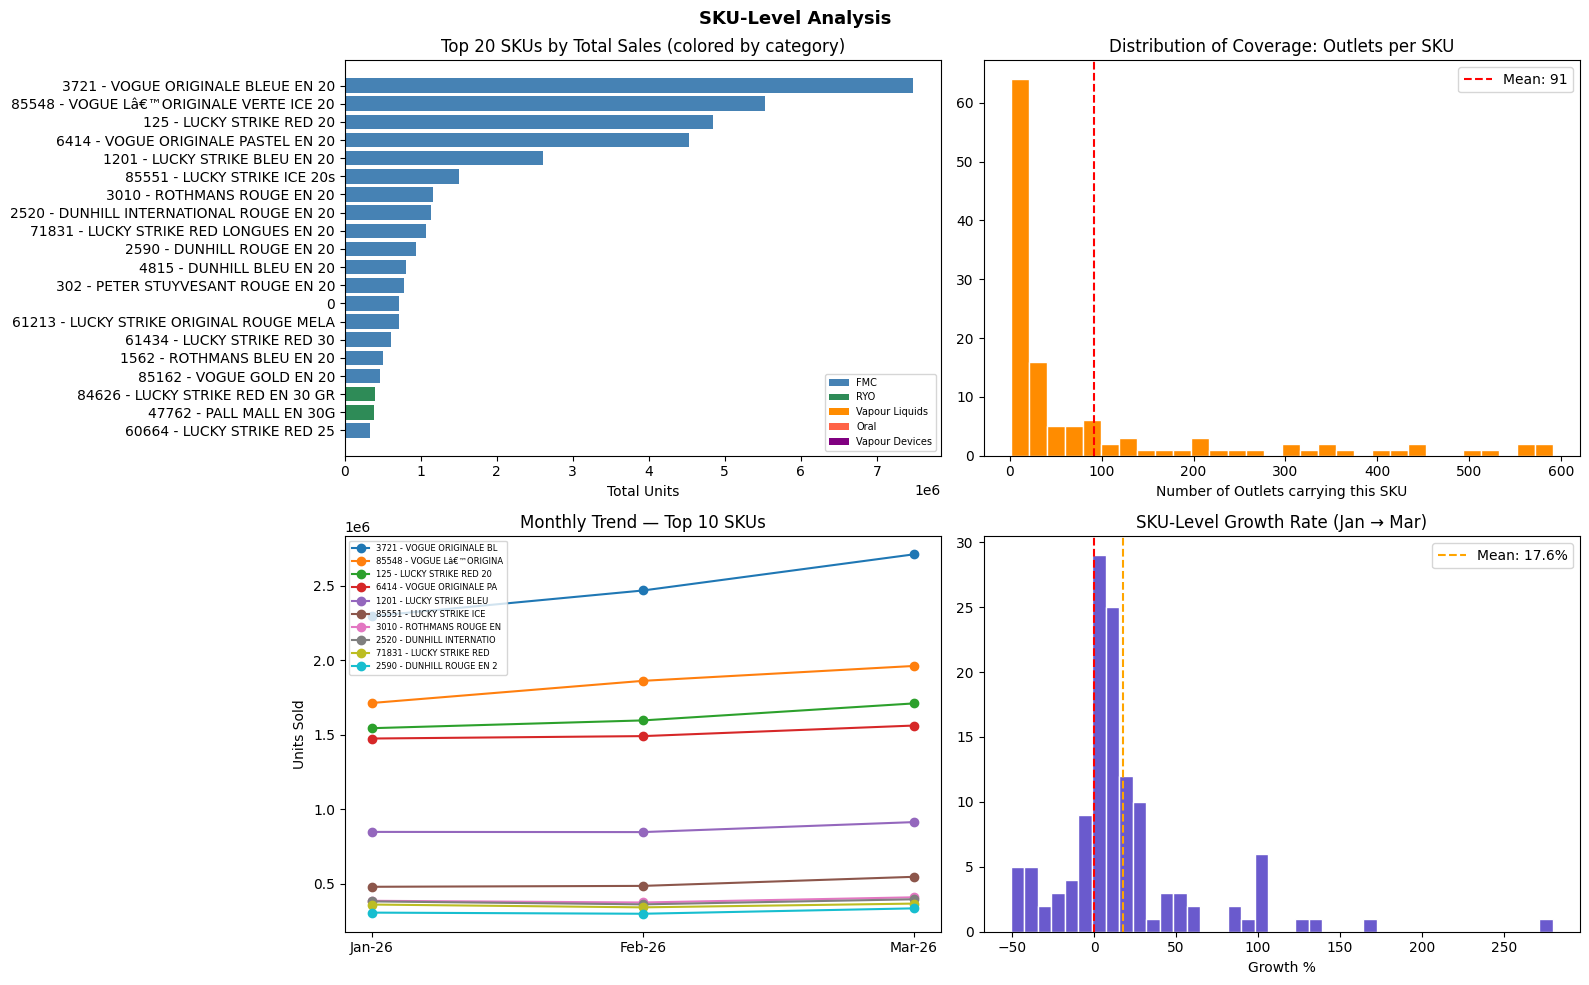


SKU summary:
  Total SKUs             : 126
  Avg outlets per SKU    : 91.4
  SKUs in 200+ outlets   : 22
  Mean Jan→Mar growth    : 17.6%


In [82]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Top 20 SKUs
top20_sku = sku_agg.head(20)
colors_cat = {'FMC':'steelblue','RYO':'seagreen','Vapour Liquids':'darkorange',
              'Oral':'tomato','Vapour Devices':'purple','0':'gray'}
bar_colors = [colors_cat.get(c,'gray') for c in top20_sku['Category']]
axes[0,0].barh(top20_sku['SKU Name'].str[:40], top20_sku['Total'], color=bar_colors)
axes[0,0].invert_yaxis()
axes[0,0].set_title('Top 20 SKUs by Total Sales (colored by category)')
axes[0,0].set_xlabel('Total Units')
# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=v, label=k) for k,v in colors_cat.items() if k != '0']
axes[0,0].legend(handles=legend_els, fontsize=7, loc='lower right')

# 2. Outlets per SKU (how widely distributed is each product)
axes[0,1].hist(sku_agg['Outlets'], bins=30, color='darkorange', edgecolor='white')
axes[0,1].set_title('Distribution of Coverage: Outlets per SKU')
axes[0,1].set_xlabel('Number of Outlets carrying this SKU')
axes[0,1].axvline(sku_agg['Outlets'].mean(), color='red', linestyle='--',
                  label=f"Mean: {sku_agg['Outlets'].mean():.0f}")
axes[0,1].legend()

# 3. Monthly trend top 10 SKUs
top10_sku = sku_agg.head(10)
for _, row in top10_sku.iterrows():
    axes[1,0].plot(MONTH_COLS, [row['Jan'],row['Feb'],row['Mar']],
                   marker='o', label=row['SKU Name'][:25], linewidth=1.5)
axes[1,0].set_title('Monthly Trend — Top 10 SKUs')
axes[1,0].set_ylabel('Units Sold')
axes[1,0].legend(fontsize=6)

# 4. SKU growth distribution
axes[1,1].hist(sku_agg['Growth_Jan_Mar%'].clip(-100,300), bins=40,
               color='slateblue', edgecolor='white')
axes[1,1].set_title('SKU-Level Growth Rate (Jan → Mar)')
axes[1,1].set_xlabel('Growth %')
axes[1,1].axvline(0, color='red', linestyle='--')
axes[1,1].axvline(sku_agg['Growth_Jan_Mar%'].mean(), color='orange', linestyle='--',
                  label=f"Mean: {sku_agg['Growth_Jan_Mar%'].mean():.1f}%")
axes[1,1].legend()

plt.suptitle('SKU-Level Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nSKU summary:")
print(f"  Total SKUs             : {len(sku_agg)}")
print(f"  Avg outlets per SKU    : {sku_agg['Outlets'].mean():.1f}")
print(f"  SKUs in 200+ outlets   : {(sku_agg['Outlets'] >= 200).sum()}")
print(f"  Mean Jan→Mar growth    : {sku_agg['Growth_Jan_Mar%'].mean():.1f}%")

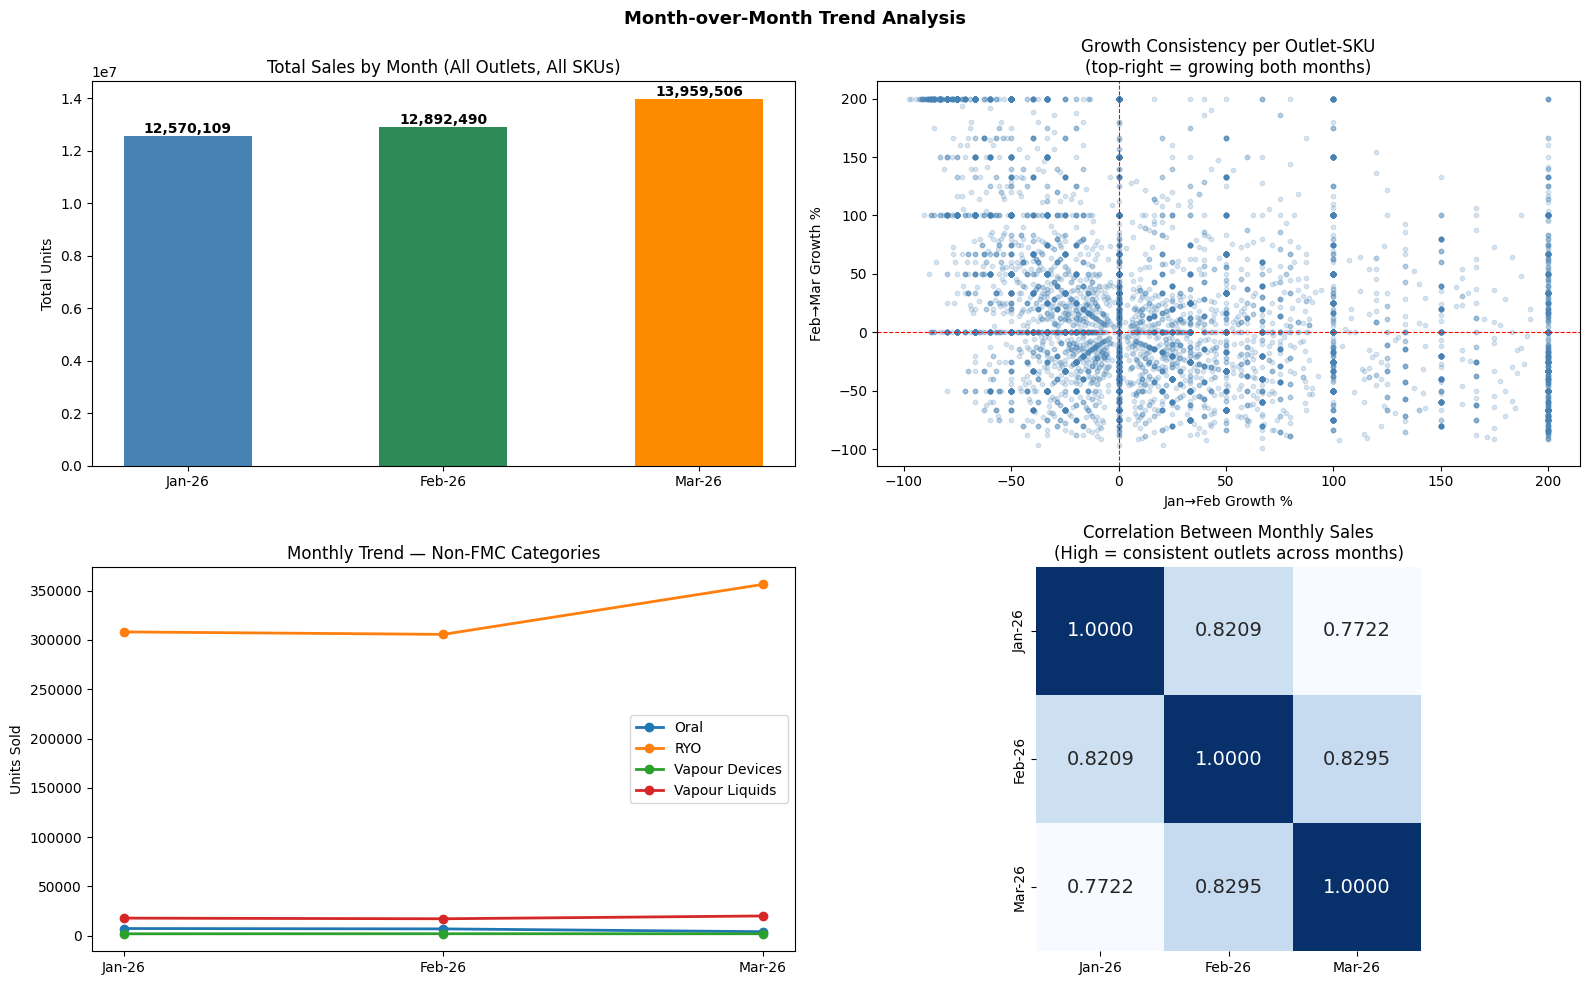

Month-over-month correlation matrix:
        Jan-26  Feb-26  Mar-26
Jan-26  1.0000  0.8209  0.7722
Feb-26  0.8209  1.0000  0.8295
Mar-26  0.7722  0.8295  1.0000


In [76]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Overall monthly total trend
monthly_totals = [df['Jan-26'].sum(), df['Feb-26'].sum(), df['Mar-26'].sum()]
axes[0,0].bar(MONTH_COLS, monthly_totals, color=['steelblue','seagreen','darkorange'], width=0.5)
for i, v in enumerate(monthly_totals):
    axes[0,0].text(i, v*1.01, f'{v:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0,0].set_title('Total Sales by Month (All Outlets, All SKUs)')
axes[0,0].set_ylabel('Total Units')
# axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

# 2. Row-level MoM growth heatmap-style scatter
axes[0,1].scatter(df['Growth_Jan_Feb'].clip(-100,200),
                  df['Growth_Feb_Mar'].clip(-100,200),
                  alpha=0.2, s=10, color='steelblue')
axes[0,1].axhline(0, color='red',  linestyle='--', linewidth=0.8)
axes[0,1].axvline(0, color='red',  linestyle='--', linewidth=0.8)
axes[0,1].set_xlabel('Jan→Feb Growth %')
axes[0,1].set_ylabel('Feb→Mar Growth %')
axes[0,1].set_title('Growth Consistency per Outlet-SKU\n(top-right = growing both months)')

# 3. Category monthly trend (excluding FMC to see small categories better)
non_fmc = df[df['Category'] != 'FMC'].groupby('Category')[MONTH_COLS].sum()
for cat in non_fmc.index:
    if cat != '0':
        axes[1,0].plot(MONTH_COLS, non_fmc.loc[cat], marker='o', label=cat, linewidth=2)
axes[1,0].set_title('Monthly Trend — Non-FMC Categories')
axes[1,0].set_ylabel('Units Sold')
axes[1,0].legend()

# 4. Correlation between Jan, Feb, Mar sales
corr = df[MONTH_COLS].corr()
sns.heatmap(corr, annot=True, fmt='.4f', cmap='Blues',
            ax=axes[1,1], square=True, cbar=False,
            annot_kws={'size':14})
axes[1,1].set_title('Correlation Between Monthly Sales\n(High = consistent outlets across months)')

plt.suptitle('Month-over-Month Trend Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Month-over-month correlation matrix:")
print(corr.round(4))

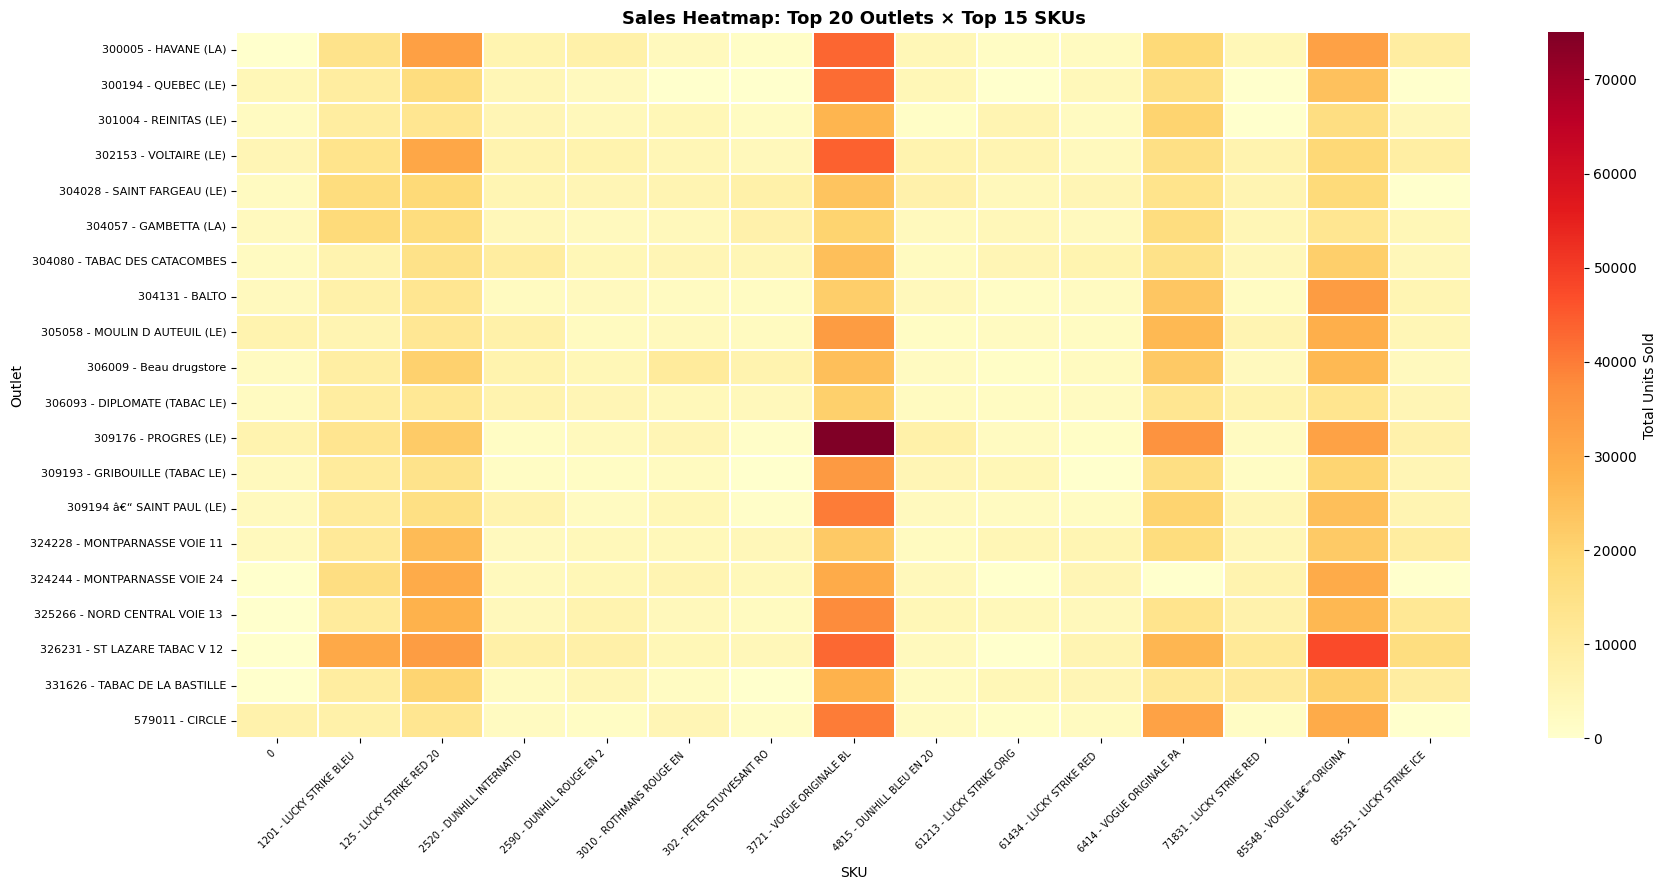

In [83]:
# Pivot: top 20 outlets vs top 15 SKUs by total sales
top_outlets_list = outlet_agg.head(20)['Local Outlet Code'].tolist()
top_skus_list    = sku_agg.head(15)['Local SKU Code'].tolist()

pivot = df[
    df['Local Outlet Code'].isin(top_outlets_list) &
    df['Local SKU Code'].isin(top_skus_list)
].pivot_table(
    index='Outlet Name', columns='SKU Name',
    values='TotalSales', aggfunc='sum', fill_value=0
)

# Shorten names
pivot.index   = pivot.index.str[:30]
pivot.columns = pivot.columns.str[:25]

fig, ax = plt.subplots(figsize=(18, 9))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            fmt='.0f', annot=False,
            cbar_kws={'label': 'Total Units Sold'})
ax.set_title('Sales Heatmap: Top 20 Outlets × Top 15 SKUs', fontsize=13, fontweight='bold')
ax.set_xlabel('SKU'); ax.set_ylabel('Outlet')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [84]:
print("=" * 65)
print("           EDA SUMMARY — Paris Sell-In Data")
print("=" * 65)

print(f"""
DATA SHAPE
  Rows         : {len(df):,}  (one per Outlet × SKU combination)
  Outlets      : {df['Local Outlet Code'].nunique()}
  SKUs         : {df['Local SKU Code'].nunique()}
  Months       : Jan-26, Feb-26, Mar-26 (3 months only)
  Missing data : None

SALES OVERVIEW
  Jan total    : {df['Jan-26'].sum():>12,.0f} units
  Feb total    : {df['Feb-26'].sum():>12,.0f} units  (+{((df['Feb-26'].sum()-df['Jan-26'].sum())/df['Jan-26'].sum()*100):.1f}%)
  Mar total    : {df['Mar-26'].sum():>12,.0f} units  (+{((df['Mar-26'].sum()-df['Feb-26'].sum())/df['Feb-26'].sum()*100):.1f}%)

CATEGORY SPLIT
  FMC (cigarettes)   : 97.3% of all volume
  RYO                :  2.5%
  Vapour + Oral      :  0.2%

KEY FINDINGS
  1. Sales are GROWING consistently month-over-month (+11% Jan→Mar)
  2. Inter-month correlation is very high (>0.99), meaning outlets
     that sold a lot in Jan also sold a lot in Feb and Mar — 
     sales behaviour is VERY consistent per outlet-SKU.
  3. A small number of outlets drive most volume (top 10 = ~{(outlet_agg.head(10)['Total'].sum()/outlet_agg['Total'].sum()*100):.0f}% of sales).
  4. Top 10 SKUs account for the bulk of FMC volume.

MODELLING RECOMMENDATION FOR APRIL FORECAST
  ✅ BEST APPROACH : Cross-sectional ML (XGBoost / LightGBM)
     - Use all 11,516 rows as training examples
     - Features: Jan sales, Feb sales, Mar sales, growth rates,
       outlet identity, SKU identity, category, outlet avg sales,
       SKU avg sales, MoM trend direction
     - Target: April sales (derived from the 3-month pattern)

  ✅ ALSO GOOD    : Statistical baseline
     - Weighted average of last 3 months
     - Exponential smoothing giving more weight to recent months

  ❌ NOT SUITABLE : Facebook Prophet (only 3 time points)
  ❌ NOT SUITABLE : ARIMA (needs 30+ time points per series)
""")
print("=" * 65)
print("NEXT STEPS: Run modelling cells when ready.")
print("=" * 65)

           EDA SUMMARY — Paris Sell-In Data

DATA SHAPE
  Rows         : 11,516  (one per Outlet × SKU combination)
  Outlets      : 663
  SKUs         : 126
  Months       : Jan-26, Feb-26, Mar-26 (3 months only)
  Missing data : None

SALES OVERVIEW
  Jan total    :   12,570,109 units
  Feb total    :   12,892,490 units  (+2.6%)
  Mar total    :   13,959,506 units  (+8.3%)

CATEGORY SPLIT
  FMC (cigarettes)   : 97.3% of all volume
  RYO                :  2.5%
  Vapour + Oral      :  0.2%

KEY FINDINGS
  1. Sales are GROWING consistently month-over-month (+11% Jan→Mar)
  2. Inter-month correlation is very high (>0.99), meaning outlets
     that sold a lot in Jan also sold a lot in Feb and Mar — 
     sales behaviour is VERY consistent per outlet-SKU.
  3. A small number of outlets drive most volume (top 10 = ~5% of sales).
  4. Top 10 SKUs account for the bulk of FMC volume.

MODELLING RECOMMENDATION FOR APRIL FORECAST
  ✅ BEST APPROACH : Cross-sectional ML (XGBoost / LightGBM)
     -

## MODELING